# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**Pneumonia Model Comparison Analysis Notebook**

Authors:
- Maria Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

## Notebook Summary

This notebook performs a comprehensive comparison of different deep learning models trained to detect pneumonia from chest X-ray images. We analyze the impact of different hyperparameters, model architectures, and data augmentation strategies.

**Models being compared:**
- AlexNet
- ResNet-18
- ResNet-50
- DenseNet-169

**Hyperparameters varied:**
- Batch size: 32, 64, 96
- Dropout strategy: Fixed (0.3, 0.5) or Custom (0.5 → 0.3)
- Data augmentation: Applied vs. Not applied

## Setup and Configuration

In [20]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules
from utils.results.constants import *
from utils.results.loading_utils import load_model_logs, extract_model_data
from utils.results.visualization_utils import *
from utils.results.table_utils import *

# Import data manipulation and display libraries
import pandas as pd
from IPython.display import display, HTML

## Data Loading

In [21]:
print("Loading model log files...")
log_files = load_model_logs()
print(f"Found {len(log_files)} potential log files.")

print("\nExtracting and processing model data...")
model_df = extract_model_data(log_files)

if model_df is None or model_df.empty:
    print("No valid model data found. Please check the log files.")
    sys.exit(1)

Loading model log files...
Loaded resnet_50_info.json
Loaded alexnet_augmented_info.json
Loaded resnet_18_info.json
Loaded resnet_18_augmented_info.json
Loaded densenet_169_augmented_info.json
Loaded densenet_169_info.json
Loaded resnet_50_augmented_info.json
Loaded alexnet_info.json
Found 8 potential log files.

Extracting and processing model data...
Data extraction complete. 66 runs processed.


In [22]:
print("\nModel DataFrame Overview:")
display(model_df)

print("\nDataFrame Info:")
model_df.info() # Show data types and non-null counts


Model DataFrame Overview:


,filename,model_base_name,augmentation,timestamp,batch_size,learning_rate,dropout_mode,exec_time,hue_combined,dropout_rate,...,false_positive_rate,precision,precision_pneumonia,recall_pneumonia,f1_pneumonia,final_val_loss,final_val_accuracy,final_val_AUC,dropout_start,dropout_end
63,alexnet_info.json,alexnet,False,2025-04-17 16:52:19,32,0.001,custom,128.81,"(alexnet, False)",NaN,...,0.448718,0.787449,0.79,1.00,0.88,0.098951,0.971374,0.987650,0.5,0.3
60,alexnet_info.json,alexnet,False,2025-04-17 16:43:00,32,0.001,fixed,157.96,"(alexnet, False)",0.3,...,0.376068,0.815514,0.82,1.00,0.90,0.131988,0.971374,0.984077,NaN,NaN
57,alexnet_info.json,alexnet,False,2025-04-17 16:34:15,32,0.001,fixed,168.34,"(alexnet, False)",0.5,...,0.282051,0.853007,0.85,0.98,0.91,0.134966,0.973282,0.984132,NaN,NaN
64,alexnet_info.json,alexnet,False,2025-04-17 16:55:46,64,0.001,custom,155.57,"(alexnet, False)",NaN,...,0.320513,0.838362,0.84,1.00,0.91,0.155305,0.971374,0.978327,0.5,0.3
61,alexnet_info.json,alexnet,False,2025-04-17 16:46:03,64,0.001,fixed,168.96,"(alexnet, False)",0.3,...,0.256410,0.864865,0.86,0.98,0.92,0.118834,0.969466,0.982103,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,densenet_169_augmented_info.json,densenet_169,True,2025-04-18 12:18:45,32,0.001,fixed,746.45,"(densenet_169, True)",0.5,...,0.277778,0.853604,0.85,0.97,0.91,0.176612,0.927481,0.971430,NaN,NaN
40,densenet_169_augmented_info.json,densenet_169,True,2025-04-18 13:16:30,64,0.001,fixed,698.76,"(densenet_169, True)",0.3,...,0.474359,0.775758,0.78,0.98,0.87,0.191033,0.923664,0.970256,NaN,NaN
37,densenet_169_augmented_info.json,densenet_169,True,2025-04-18 12:32:35,64,0.001,fixed,650.36,"(densenet_169, True)",0.5,...,0.444444,0.786885,0.79,0.98,0.87,0.218971,0.916031,0.966636,NaN,NaN
41,densenet_169_augmented_info.json,densenet_169,True,2025-04-18 13:29:32,96,0.001,fixed,708.60,"(densenet_169, True)",0.3,...,0.380342,0.812236,0.81,0.99,0.89,0.217142,0.916031,0.965645,NaN,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 63 to 38
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   filename             66 non-null     object  
 1   model_base_name      66 non-null     category
 2   augmentation         66 non-null     bool    
 3   timestamp            66 non-null     object  
 4   batch_size           66 non-null     int64   
 5   learning_rate        66 non-null     float64 
 6   dropout_mode         66 non-null     object  
 7   exec_time            66 non-null     float64 
 8   hue_combined         66 non-null     category
 9   dropout_rate         48 non-null     float64 
 10  dropout_setting      66 non-null     category
 11  test_accuracy        66 non-null     float64 
 12  test_loss            66 non-null     float64 
 13  test_auc             66 non-null     float64 
 14  tn                   66 non-null     int64   
 15  fp          

In [23]:
print("\n=== Data Summary ===\n")

print(f"Total models: {len(model_df)}")
print(f"Unique models: {model_df['model_base_name'].nunique()} ({', '.join(model_df['model_base_name'].unique())})")
print(f"Augmentation status counts:\n{model_df['augmentation'].value_counts()}")
print(f"Batch sizes tested: {sorted(model_df['batch_size'].dropna().unique())}")
print(f"Dropout strategies: {sorted(model_df['dropout_setting'].dropna().unique())}")


=== Data Summary ===

Total models: 66
Unique models: 4 (alexnet, resnet_18, resnet_50, densenet_169)
Augmentation status counts:
augmentation
False    33
True     33
Name: count, dtype: int64
Batch sizes tested: [np.int64(32), np.int64(64), np.int64(96)]
Dropout strategies: ['custom_0.5_0.3', 'fixed_0.3', 'fixed_0.5']


## Overall Model Performance

### Best Model Execution Comparison

In [24]:
# Print the best model for each base model
print("\nBest Model Execution Comparison:")
best_models_table = get_best_model_executions(
    model_df, 
    metrics=['fn', 'false_negative_rate', 'test_auc', 'test_accuracy', 'dropout_setting', 'batch_size', 'exec_time']
)
display(best_models_table)


Best Model Execution Comparison:


,Model,Augmentation,FN Count,FNR,AUC,Accuracy,Dropout Strategy,Batch Size,Execution Time (s)
0,alexnet,True,0,0.00%,0.9704,0.8558,fixed_0.5,96,568.25
1,resnet_18,True,1,0.26%,0.9736,0.8798,fixed_0.5,64,343.93
2,resnet_50,True,0,0.00%,0.9791,0.8862,fixed_0.3,32,655.40
3,densenet_169,False,1,0.26%,0.9514,0.8077,fixed_0.5,96,829.14


### Model AUC Comparison


Model AUC Comparison:


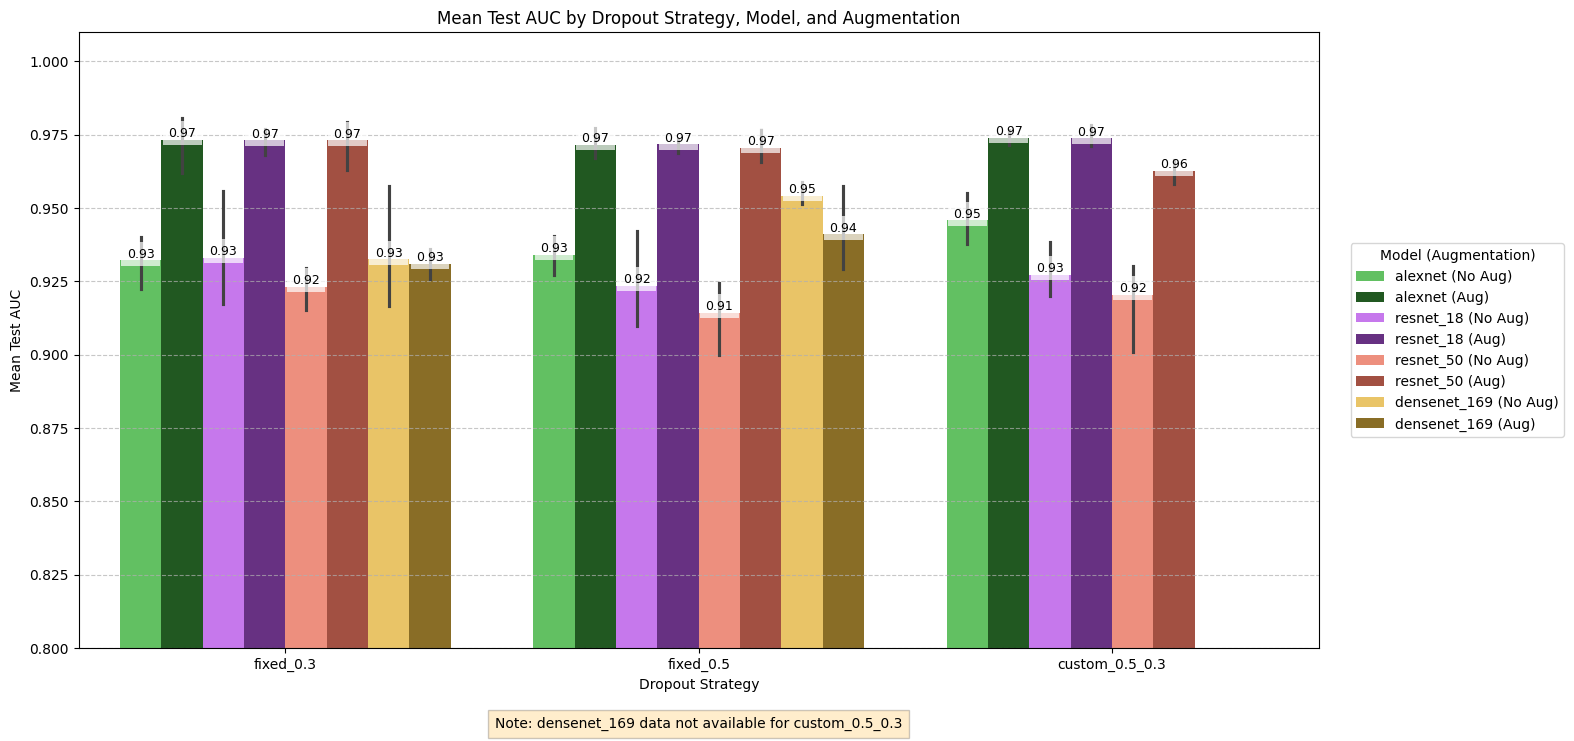

,Dropout Strategy,Model,Augmentation,Mean AUC,Lower CI (95%),Upper CI (95%)
0,fixed_0.3,alexnet,False,0.932159,0.909755,0.954563
1,fixed_0.3,alexnet,True,0.973289,0.948764,0.997814
2,fixed_0.3,resnet_18,False,0.933069,0.882844,0.983293
3,fixed_0.3,resnet_18,True,0.973106,0.961503,0.984710
4,fixed_0.3,resnet_50,False,0.923112,0.905184,0.941039
5,fixed_0.3,resnet_50,True,0.973066,0.951251,0.994881
6,fixed_0.3,densenet_169,False,0.932533,0.877884,0.987183
7,fixed_0.3,densenet_169,True,0.930934,0.918157,0.943711
8,fixed_0.5,alexnet,False,0.933945,0.917171,0.950719
9,fixed_0.5,alexnet,True,0.971567,0.958417,0.984716


In [25]:
# Generate and display model AUC comparison
print("\nModel AUC Comparison:")
plot_metric_comparison(model_df, metric='test_auc', title_metric='AUC', ylim=(0.8, 1.01))
auc_data_df = get_metric_comparison_data(model_df, metric='test_auc', title_metric='AUC')
display(auc_data_df)

### Model Accuracy Comparison


Model Accuracy Comparison:


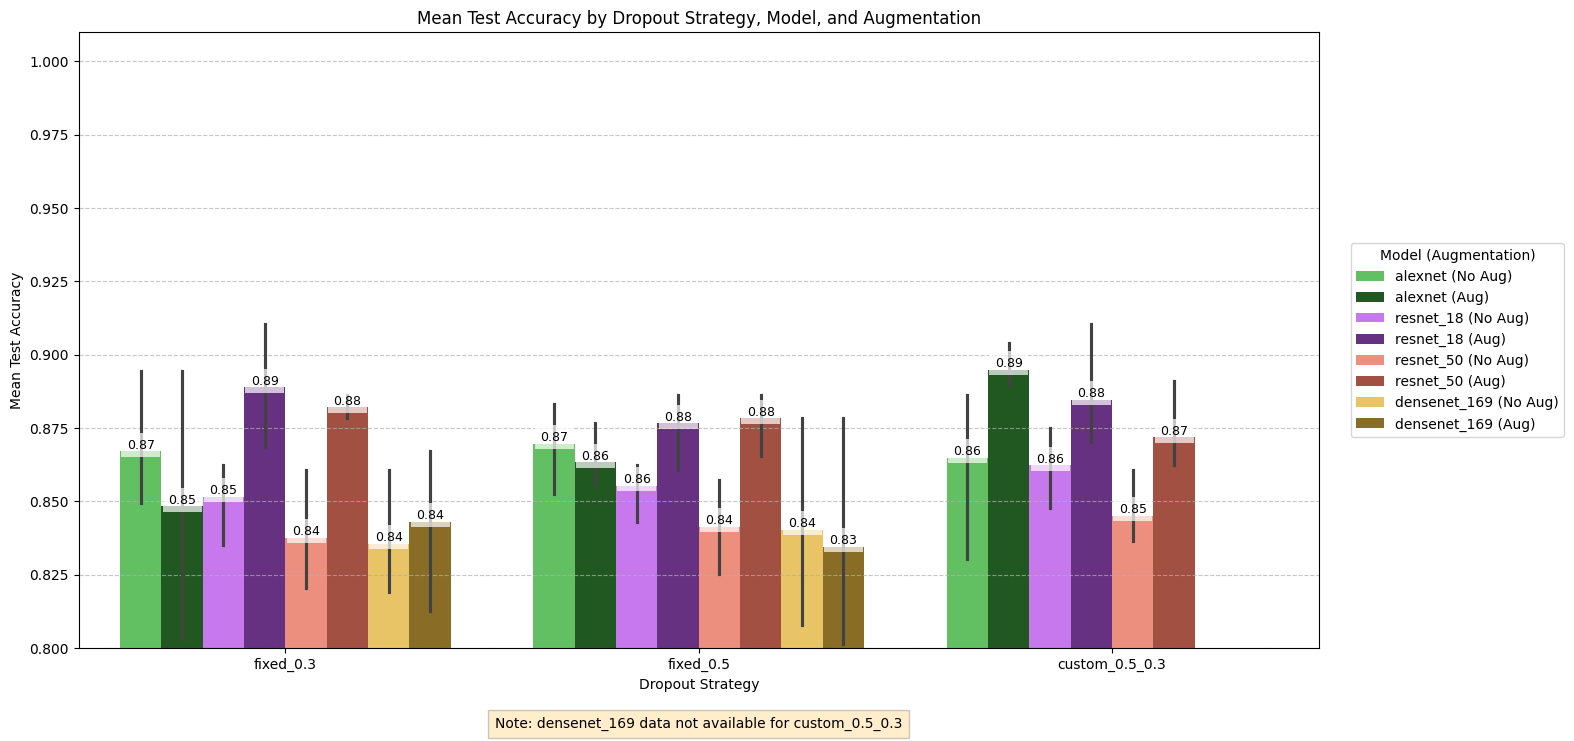

,Dropout Strategy,Model,Augmentation,Mean Accuracy,Lower CI (95%),Upper CI (95%)
0,fixed_0.3,alexnet,False,0.866987,0.807538,0.926436
1,fixed_0.3,alexnet,True,0.848291,0.734827,0.961755
2,fixed_0.3,resnet_18,False,0.851496,0.815373,0.887618
3,fixed_0.3,resnet_18,True,0.888889,0.837085,0.940693
4,fixed_0.3,resnet_50,False,0.837607,0.786264,0.888950
5,fixed_0.3,resnet_50,True,0.881944,0.871926,0.891963
6,fixed_0.3,densenet_169,False,0.835470,0.780548,0.890392
7,fixed_0.3,densenet_169,True,0.842949,0.773881,0.912016
8,fixed_0.5,alexnet,False,0.869658,0.830993,0.908324
9,fixed_0.5,alexnet,True,0.863248,0.834449,0.892047


In [26]:
# Generate and display model Accuracy comparison
print("\nModel Accuracy Comparison:")
plot_metric_comparison(model_df, metric='test_accuracy', title_metric='Accuracy', ylim=(0.8, 1.01))
acc_data_df = get_metric_comparison_data(model_df, metric='test_accuracy', title_metric='Accuracy')
display(acc_data_df)

### Model Execution Time Comparison


Execution Time Comparison:


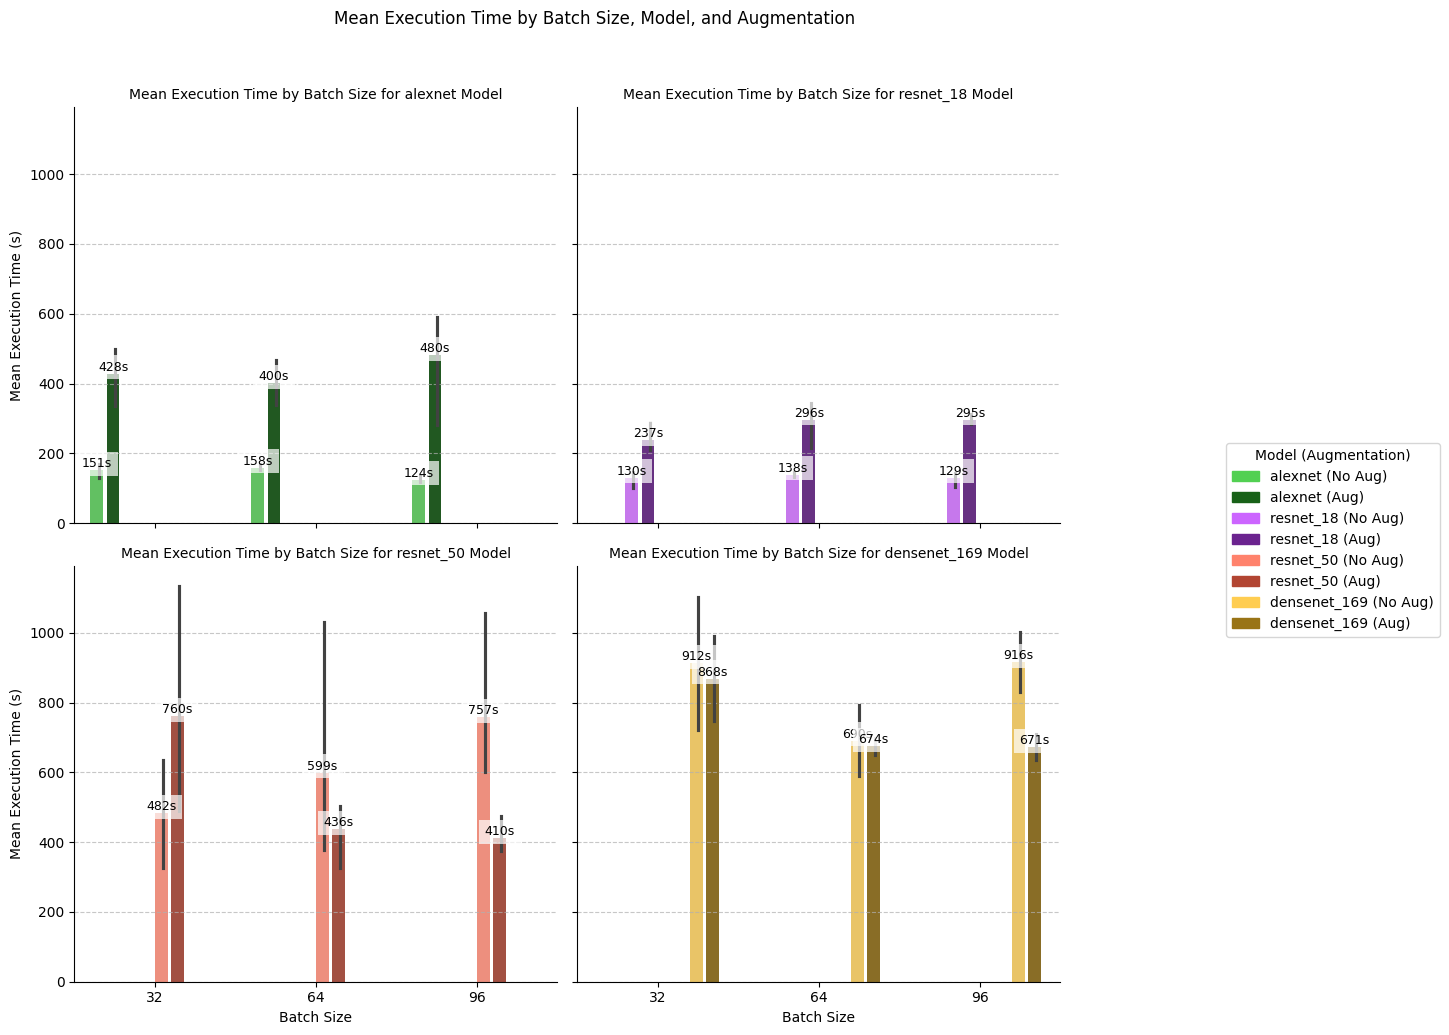

,Model,Augmentation,Batch Size,Mean Execution Time (s),Best Case (Min Time),Worst Case (Max Time),Lower CI (95%),Upper CI (95%),Sample Size
0,alexnet,False,32,151.703333,128.81,168.34,100.792773,202.613894,3
1,alexnet,False,64,158.813333,151.91,168.96,136.516203,181.110463,3
2,alexnet,False,96,124.780000,117.12,134.14,103.325965,146.234035,3
3,alexnet,True,32,428.003333,336.56,499.58,221.059701,634.946966,3
4,alexnet,True,64,400.753333,339.50,468.13,240.443848,561.062819,3
5,alexnet,True,96,480.493333,282.48,590.75,53.586316,907.400350,3
6,resnet_18,False,32,130.616667,100.15,147.30,64.974023,196.259310,3
7,resnet_18,False,64,138.596667,132.36,145.08,122.788641,154.404692,3
8,resnet_18,False,96,129.340000,103.25,143.33,73.162825,185.517175,3
9,resnet_18,True,32,237.110000,208.95,285.51,132.522150,341.697850,3


In [27]:
# Generate and display execution time comparison
print("\nExecution Time Comparison:")
plot_execution_time_comparison(model_df)
get_execution_time_comparison_data(model_df)

### Best Model Configurations

In [40]:
# Define the number of top models to display
top_n = 25

# Top models by FNR, using AUC and accuracy as tiebreakers
print(f"\nTop {top_n} Models by False Negative Rate (with AUC and Accuracy as tiebreakers)")
balanced_table = create_best_models_table(
    model_df, 
    top_n=top_n, 
    sort_by=[
        ('false_negative_rate', True),  # Lower FNR is better
        ('test_auc', False),  # Higher AUC is better
        ('test_accuracy', False)  # Higher accuracy is better
    ]
)
display(HTML(balanced_table.to_html(index=False)))  # Display as HTML table


# Top models by AUC, using accuracy as tiebreaker
print(f"\nTop {top_n} Models by AUC Score (with Accuracy as tiebreaker):")
best_auc_table = create_best_models_table(
    model_df, 
    top_n=top_n, 
    sort_by=[
        ('test_auc', False),  # Higher AUC is better
        ('test_accuracy', False)  # Higher accuracy is better
    ]
)
display(HTML(best_auc_table.to_html(index=False)))  # Display as HTML table

print("Note: The sorting is done with higher precision, therefore the order may not be exactly as expected.")


Top 25 Models by False Negative Rate (with AUC and Accuracy as tiebreakers)


Model,Augmentation,Batch Size,Dropout Strategy,Accuracy,AUC,Precision (Pneu),Recall (Pneu),F1 (Pneu),FN Rate,FN Count,Execution Time
resnet_50,True,32,fixed_0.3,0.88621795,0.97913105,0.8500,1.0000,0.9200,0.0000%,0,655.40s
alexnet,True,96,fixed_0.5,0.85576922,0.97040324,0.8100,1.0000,0.9000,0.0000%,0,568.25s
resnet_50,False,64,fixed_0.5,0.82532054,0.89983016,0.7800,1.0000,0.8800,0.0000%,0,377.32s
alexnet,True,32,fixed_0.3,0.84775639,0.98050077,0.8100,1.0000,0.8900,0.2564%,1,499.58s
alexnet,True,64,fixed_0.3,0.89423078,0.97732851,0.8600,1.0000,0.9200,0.2564%,1,468.13s
resnet_50,True,64,fixed_0.3,0.88141024,0.97707101,0.8400,1.0000,0.9100,0.2564%,1,504.29s
resnet_18,True,64,fixed_0.5,0.87980771,0.97361933,0.8400,1.0000,0.9100,0.2564%,1,343.93s
resnet_18,True,96,fixed_0.5,0.86057693,0.97240302,0.8200,1.0000,0.9000,0.2564%,1,313.06s
resnet_50,True,96,fixed_0.5,0.86538464,0.96916502,0.8200,1.0000,0.9000,0.2564%,1,373.57s
densenet_169,False,96,fixed_0.5,0.80769229,0.95141902,0.7700,1.0000,0.8700,0.2564%,1,829.14s



Top 25 Models by AUC Score (with Accuracy as tiebreaker):


Model,Augmentation,Batch Size,Dropout Strategy,Accuracy,AUC,Precision (Pneu),Recall (Pneu),F1 (Pneu),FN Rate,FN Count,Execution Time
alexnet,True,32,fixed_0.3,0.84775639,0.98050077,0.8100,1.0000,0.8900,0.2564%,1,499.58s
resnet_50,True,32,fixed_0.3,0.88621795,0.97913105,0.8500,1.0000,0.9200,0.0000%,0,655.40s
resnet_18,True,32,custom_0.5_0.3,0.91025639,0.97813938,0.8800,0.9900,0.9300,1.2821%,5,285.51s
alexnet,True,32,fixed_0.5,0.87660259,0.97734495,0.8400,0.9900,0.9100,0.5128%,2,336.56s
alexnet,True,64,fixed_0.3,0.89423078,0.97732851,0.8600,1.0000,0.9200,0.2564%,1,468.13s
resnet_50,True,64,fixed_0.3,0.88141024,0.97707101,0.8400,1.0000,0.9100,0.2564%,1,504.29s
resnet_18,True,64,fixed_0.3,0.91025639,0.97692856,0.8800,0.9900,0.9300,1.0256%,4,214.65s
alexnet,True,64,custom_0.5_0.3,0.89102566,0.97665461,0.8600,0.9900,0.9200,1.0256%,4,394.63s
resnet_50,True,64,fixed_0.5,0.88621795,0.97650121,0.8500,0.9900,0.9200,1.0256%,4,478.32s
resnet_18,True,32,fixed_0.3,0.88782054,0.97449047,0.8500,0.9900,0.9200,0.5128%,2,216.87s


Note: The sorting is done with higher precision, therefore the order may not be exactly as expected.


## Impact of Hyperparameters

### Data Augmentation on Performance


Impact of Data Augmentation on Performance:


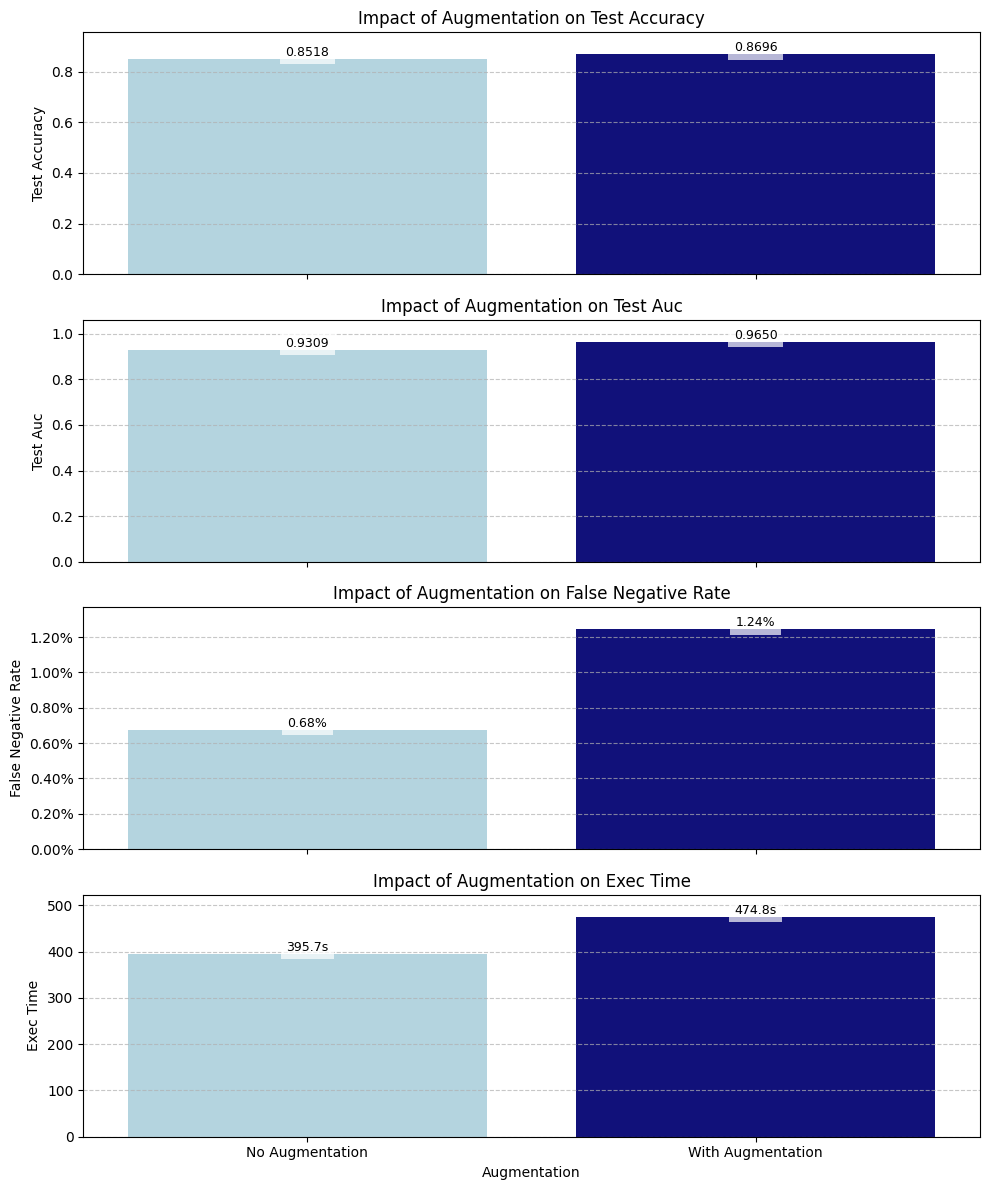

,test_accuracy,test_auc,false_negative_rate,exec_time
augmentation,,,,
False,0.851836,0.930896,0.006760,395.736364
True,0.869610,0.965033,0.012432,474.775455


In [29]:
# Analyze impact of data augmentation
print("\nImpact of Data Augmentation on Performance:")
plot_hyperparameter_impact(
    model_df, 
    group_var='augmentation',
    metrics=['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time'],
    # Using a simple palette for True/False values
    palette=AUG_IMPACT_PALETTE
)

aug_impact = model_df.groupby('augmentation')[['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time']].mean()
display(aug_impact)

### Batch Size on Performance


Impact of Batch Size on Performance:


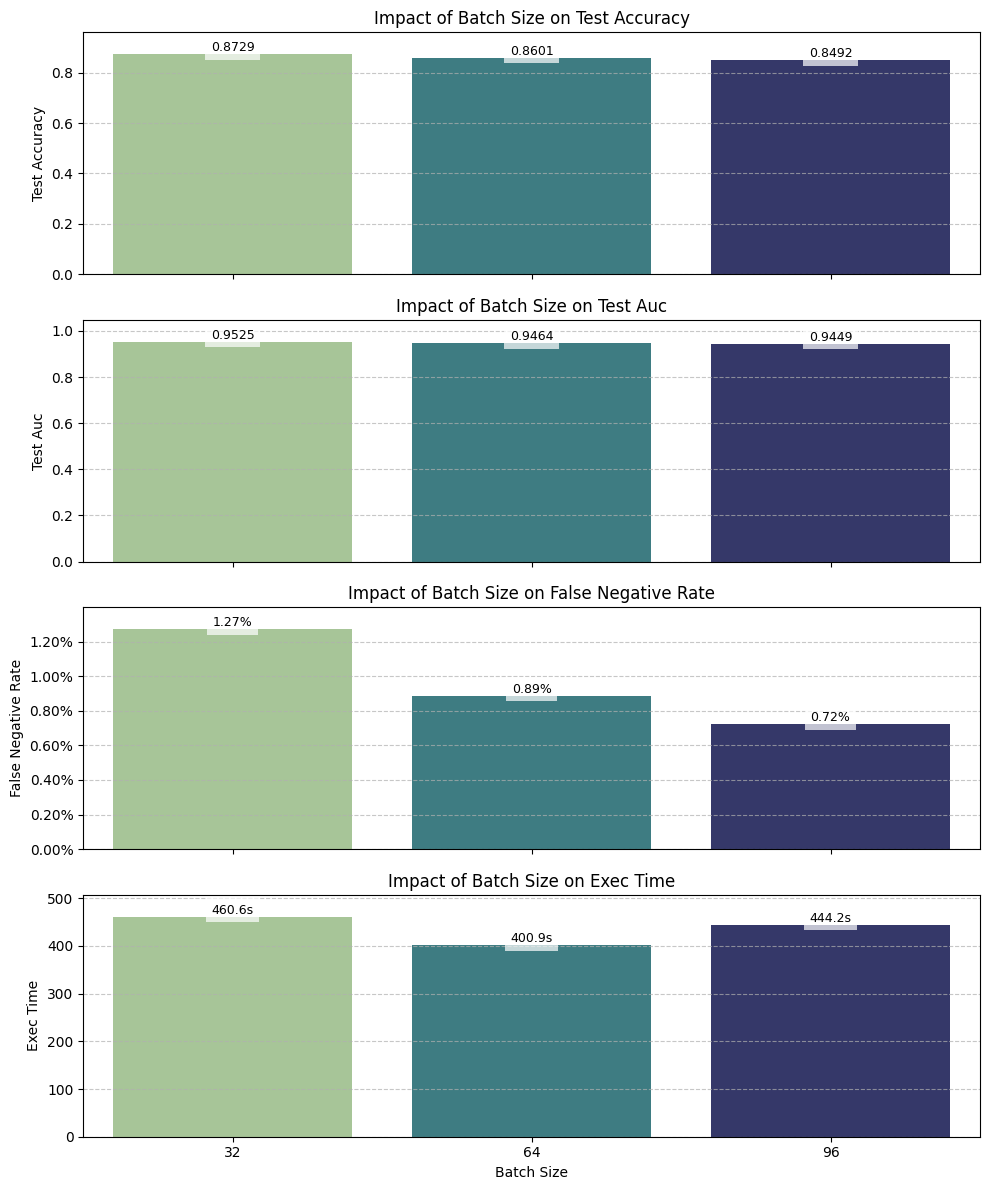

,test_accuracy,test_auc,false_negative_rate,exec_time
batch_size,,,,
32,0.872888,0.952502,0.012704,460.592727
64,0.860067,0.946447,0.008858,400.950000
96,0.849213,0.944945,0.007226,444.225000


In [30]:
# Analyze impact of batch size
print("\nImpact of Batch Size on Performance:")
plot_hyperparameter_impact(
    model_df, 
    group_var='batch_size',
    metrics=['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time'],
    palette='crest'
)

batch_impact = model_df.groupby('batch_size')[['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time']].mean()
display(batch_impact)

### Dropout Strategy on Performance


Impact of Dropout Strategy on Performance:


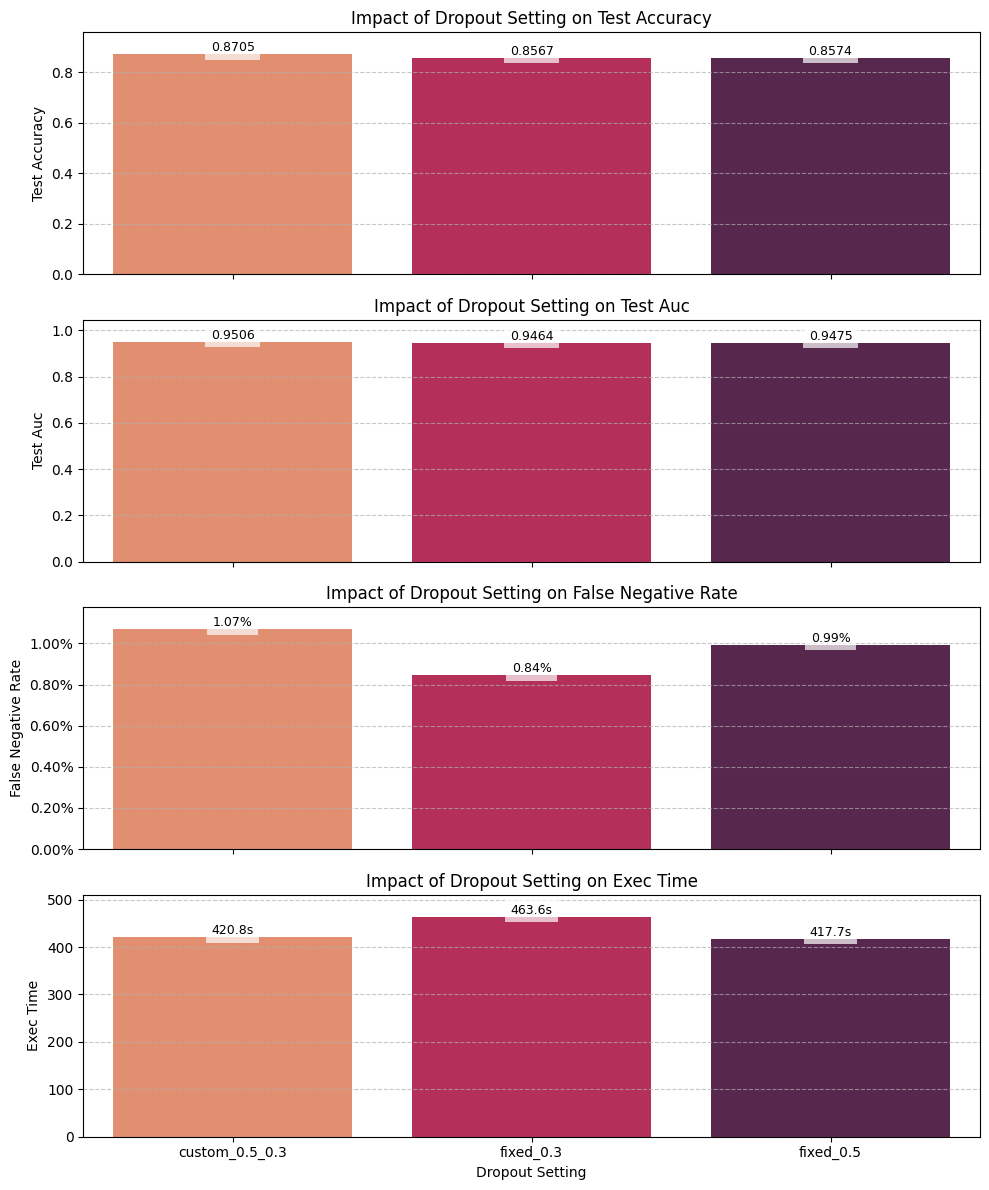

,test_accuracy,test_auc,false_negative_rate,exec_time
dropout_setting,,,,
custom_0.5_0.3,0.870548,0.950595,0.010684,420.81000
fixed_0.3,0.856704,0.946408,0.008440,463.64000
fixed_0.5,0.857372,0.947548,0.009936,417.70625


In [31]:
# Analyze impact of dropout strategy
print("\nImpact of Dropout Strategy on Performance:")
plot_hyperparameter_impact(
    model_df, 
    group_var='dropout_setting',
    metrics=['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time'],
    palette='rocket_r'
)

dropout_impact = model_df.groupby('dropout_setting', observed=True)[['test_accuracy', 'test_auc', 'false_negative_rate', 'exec_time']].mean()
display(dropout_impact)

## Qualitative Analysis

### False Negative Analysis


3. False Negative Rate Comparison (Critical for Medical Applications):


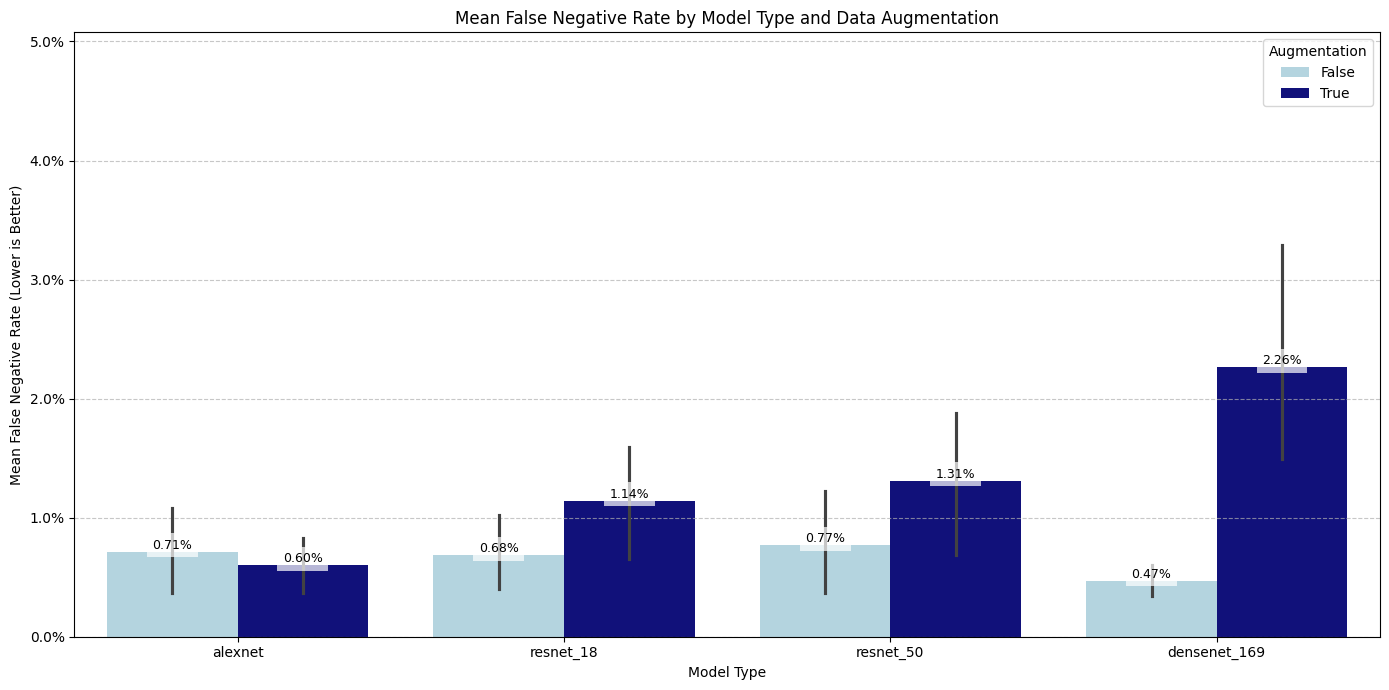

,Model,Augmentation,Mean False Negative Rate,Best Case (Min FNR),Worst Case (Max FNR),Lower CI (95%),Upper CI (95%),Sample Size
0,alexnet,False,0.007123,0.002564,0.017949,0.002630,0.011615,9
1,alexnet,True,0.005983,0.000000,0.010256,0.003196,0.008770,9
2,resnet_18,False,0.006838,0.002564,0.015385,0.002774,0.010901,9
3,resnet_18,True,0.011396,0.002564,0.028205,0.005312,0.017480,9
4,resnet_50,False,0.007692,0.000000,0.017949,0.002667,0.012717,9
5,resnet_50,True,0.013105,0.000000,0.025641,0.005507,0.020703,9
6,densenet_169,False,0.004701,0.002564,0.007692,0.002675,0.006726,6
7,densenet_169,True,0.022650,0.012821,0.046154,0.009312,0.035987,6


In [32]:
# Generate and display false negative rate comparison
print("\n3. False Negative Rate Comparison (Critical for Medical Applications):")
plot_false_negative_comparison(model_df)
get_false_negative_comparison_data(model_df)

### Feature Correlation Analysis


Correlation Matrix of Numerical Variables:


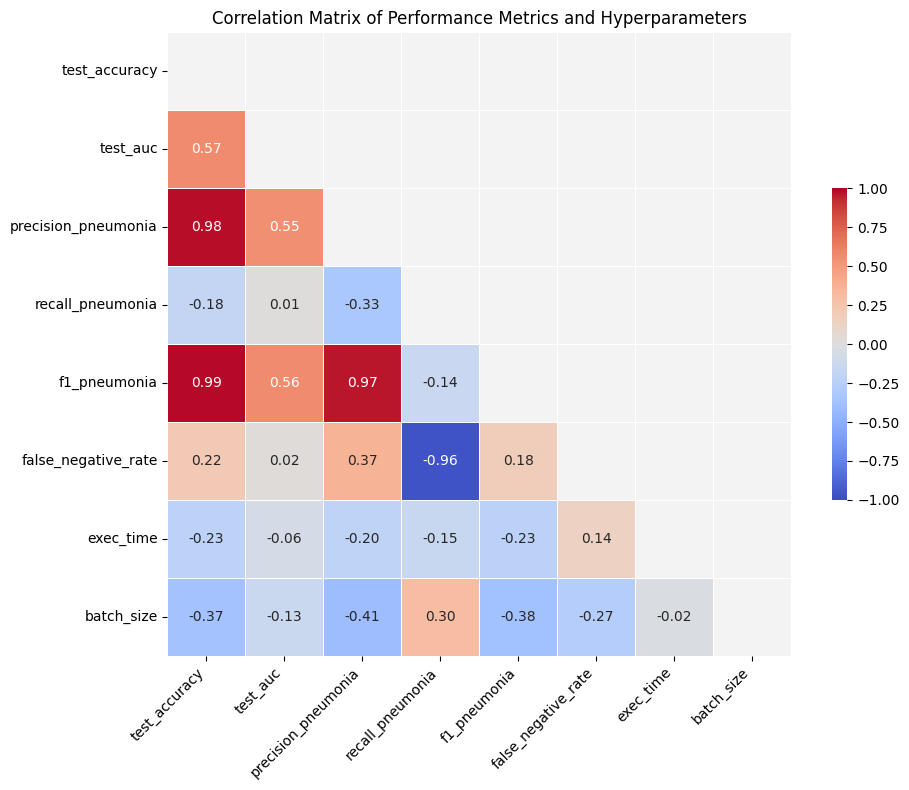

In [33]:
# Create correlation matrix of numerical variables
print("\nCorrelation Matrix of Numerical Variables:")
plot_correlation_matrix(model_df)

## Dicussion of Trade-offs

### Data Augmentation Trade-offs


Impact of Data Augmentation by Model:


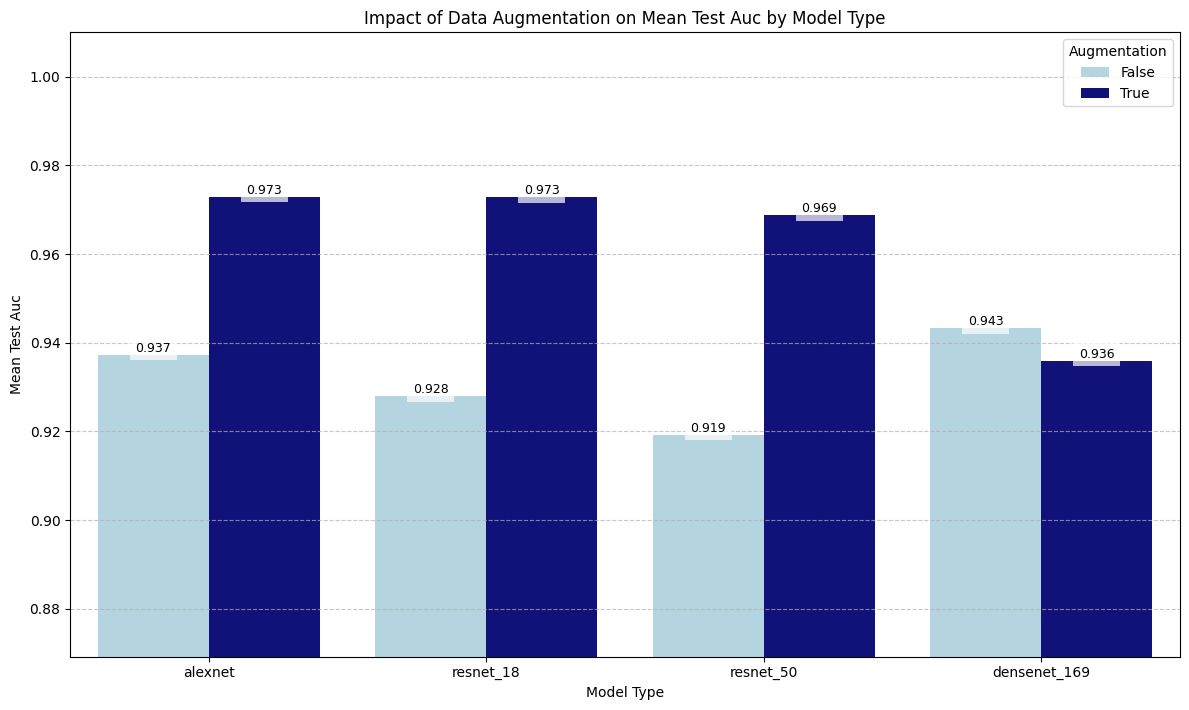

In [34]:
# Generate and display augmentation impact by model
print("\nImpact of Data Augmentation by Model:")
plot_aug_impact_by_model(model_df)

### Efficiency Trade-offs


Model Efficiency Tradeoff (AUC vs. Time):


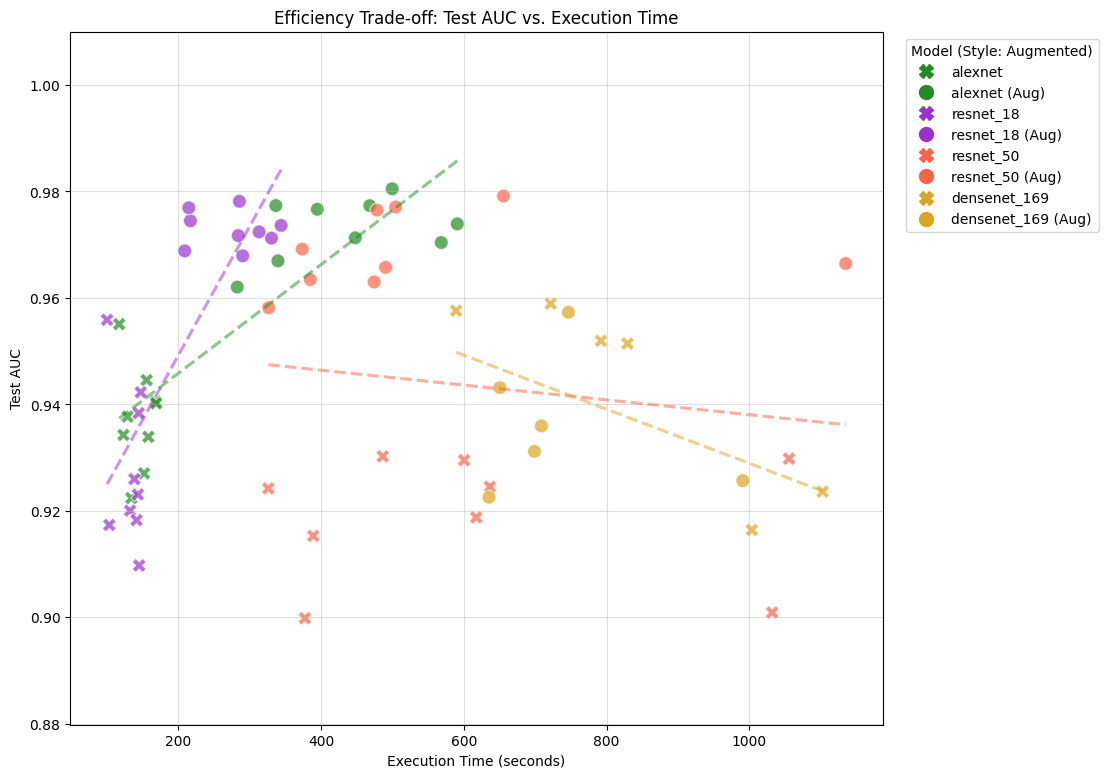

In [35]:
# Generate and display efficiency tradeoff
print("\nModel Efficiency Tradeoff (AUC vs. Time):")
plot_efficiency_tradeoff(model_df)

### TO BE CHANGED


Precision-Recall Tradeoff Analysis:


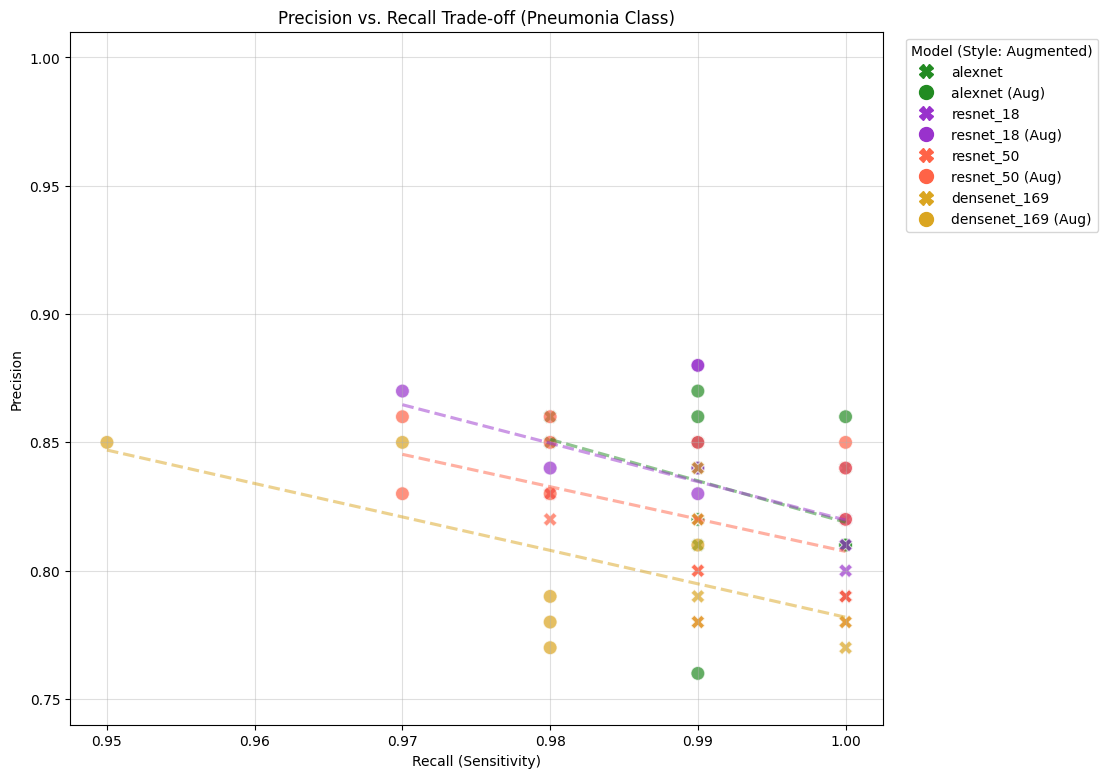

In [36]:
# Generate and display precision-recall tradeoff
print("\nPrecision-Recall Tradeoff Analysis:")
plot_precision_recall_tradeoff(model_df)

## Final Recommendations

In [37]:
print("\n=== Final Recommendations ===")

# Find best overall based on AUC
best_overall_idx = model_df['test_auc'].idxmax()
if pd.notna(best_overall_idx):
    best_overall = model_df.loc[best_overall_idx]
    print(f"\nBest Overall Model Configuration (by AUC):")
    print(f"- Model: {best_overall['model_base_name']}")
    print(f"- Augmented: {best_overall['augmentation']}")
    print(f"- Batch Size: {int(best_overall['batch_size'])}")
    print(f"- Dropout Strategy: {best_overall['dropout_setting']}")
    print(f"- Test AUC: {best_overall['test_auc']:.4f}")
    print(f"- Test Accuracy: {best_overall.get('test_accuracy', 'N/A'):.4f}")
    print(f"- Precision (Pneu): {best_overall.get('precision_pneumonia', 'N/A'):.4f}")
    print(f"- Recall (Pneu): {best_overall.get('recall_pneumonia', 'N/A'):.4f}")
    print(f"- False Negative Rate: {best_overall.get('false_negative_rate', 'N/A'):.2%}")
    print(f"- False Negatives (Count): {int(best_overall.get('fn', 'N/A'))}")
else:
    print("\nCould not determine the best overall model (missing AUC data).")


# Find best for minimizing false negatives
best_fnr_idx = model_df['false_negative_rate'].idxmin()
if pd.notna(best_fnr_idx):
    best_fnr = model_df.loc[best_fnr_idx]
    print("\nBest Model for Minimizing False Negatives:")
    print(f"- Model: {best_fnr['model_base_name']}")
    print(f"- Augmented: {best_fnr['augmentation']}")
    print(f"- Batch Size: {int(best_fnr['batch_size'])}")
    print(f"- Dropout Strategy: {best_fnr['dropout_setting']}")
    print(f"- False Negative Rate: {best_fnr['false_negative_rate']:.2%}")
    print(f"- False Negatives (Count): {int(best_fnr.get('fn', 'N/A'))}")
    print(f"- Test AUC: {best_fnr['test_auc']:.4f}")
    print(f"- Test Accuracy: {best_fnr.get('test_accuracy', 'N/A'):.4f}")
else:
    print("\nCould not determine the best model for minimizing false negatives (missing FNR data).")


=== Final Recommendations ===

Best Overall Model Configuration (by AUC):
- Model: alexnet
- Augmented: True
- Batch Size: 32
- Dropout Strategy: fixed_0.3
- Test AUC: 0.9805
- Test Accuracy: 0.8478
- Precision (Pneu): 0.8100
- Recall (Pneu): 1.0000
- False Negative Rate: 0.26%
- False Negatives (Count): 1

Best Model for Minimizing False Negatives:
- Model: alexnet
- Augmented: True
- Batch Size: 96
- Dropout Strategy: fixed_0.5
- False Negative Rate: 0.00%
- False Negatives (Count): 0
- Test AUC: 0.9704
- Test Accuracy: 0.8558


## Conclusion

In [38]:
print("\n=== Conclusion ===")

print("Based on the analysis, we can draw the following conclusions:")

# Use previously found best models if available
if 'best_overall' in locals() and pd.notna(best_overall_idx):
    print("\n1. For best overall performance (prioritizing AUC):")
    print(f"   - Model: {best_overall['model_base_name']}")
    print(f"   - Configuration: Augmented={best_overall['augmentation']}, BS={int(best_overall['batch_size'])}, Dropout={best_overall['dropout_setting']}")
else:
    print("\n1. Best overall performance could not be determined.")
if 'best_fnr' in locals() and pd.notna(best_fnr_idx):
    print("\n2. For medical applications (prioritizing low False Negatives):")
    print(f"   - Model: {best_fnr['model_base_name']}")
    print(f"   - Configuration: Augmented={best_fnr['augmentation']}, BS={int(best_fnr['batch_size'])}, Dropout={best_fnr['dropout_setting']}")
else:
    print("\n2. Best configuration for minimizing false negatives could not be determined.")


# Model-specific recommendations
print("\n3. Model-specific observations:")
model_specific_recommendations = []
# Use observed=False to include all categories, even if some combinations didn't run/log
for model in model_df['model_base_name'].cat.categories:
    model_data = model_df[model_df['model_base_name'] == model]
    if not model_data.empty:
        best_config_idx = model_data['test_auc'].idxmax()
        if pd.notna(best_config_idx):
            best_config = model_data.loc[best_config_idx]
            # Compare mean AUC for augmented vs non-augmented for this model
            aug_means = model_data.groupby('augmentation')['test_auc'].mean()
            aug_helps = aug_means.get(True, -1) > aug_means.get(False, -1) # Check if True mean > False mean
            model_specific_recommendations.append({
                'model': model,
                'best_batch_size': int(best_config['batch_size']),
                'best_dropout': best_config['dropout_setting'],
                'augmentation_helps': aug_helps,
                'best_auc': best_config['test_auc']
            })
        else:
            model_specific_recommendations.append({'model': model, 'error': 'No valid AUC found'})

for rec in model_specific_recommendations:
    if 'error' in rec:
        print(f"   - {rec['model']}: Could not determine best config ({rec['error']}).")
    else:
        print(f"   - {rec['model']}: Best AUC ({rec['best_auc']:.4f}) achieved with BS={rec['best_batch_size']}, Dropout={rec['best_dropout']}. " +
            f"Data augmentation generally {'helped' if rec['augmentation_helps'] else 'did not help'} this model.")

# Summarize key findings using pre-calculated impact tables if available
print("\n4. General Hyperparameter Trends:")
if 'aug_impact' in locals() and not aug_impact.empty:
    try:
        aug_comparison = aug_impact.loc[True, 'test_auc'] > aug_impact.loc[False, 'test_auc']
        print(f"   - Data augmentation {'improved' if aug_comparison else ('did not improve' if aug_impact.loc[True, 'test_auc'] < aug_impact.loc[False, 'test_auc'] else 'had no average effect on')} AUC on average.")
    except KeyError:
        print("   - Could not compare average augmentation impact (missing data).")
else:
    print("   - Augmentation impact analysis data not available.")

if 'batch_impact' in locals() and not batch_impact.empty:
    try:
        # Compare largest vs smallest batch size tested
        bs_max = batch_impact.index.max()
        bs_min = batch_impact.index.min()
        bs_comparison = batch_impact.loc[bs_max, 'test_auc'] > batch_impact.loc[bs_min, 'test_auc']
        print(f"   - Larger batch sizes generally {'improved' if bs_comparison else 'did not improve'} average AUC, but increased average training time.")
    except KeyError:
        print("   - Could not compare average batch size impact (missing data).")
else:
    print("   - Batch size impact analysis data not available.")

if 'dropout_impact' in locals() and not dropout_impact.empty:
    try:
        best_dropout_mode = dropout_impact['test_auc'].idxmax()
        print(f"   - '{best_dropout_mode}' dropout mode yielded the best average AUC.")
    except (KeyError, ValueError):
        print("   - Could not determine the best average dropout mode (missing data).")
else:
    print("   - Dropout impact analysis data not available.")


=== Conclusion ===
Based on the analysis, we can draw the following conclusions:

1. For best overall performance (prioritizing AUC):
   - Model: alexnet
   - Configuration: Augmented=True, BS=32, Dropout=fixed_0.3

2. For medical applications (prioritizing low False Negatives):
   - Model: alexnet
   - Configuration: Augmented=True, BS=96, Dropout=fixed_0.5

3. Model-specific observations:
   - alexnet: Best AUC (0.9805) achieved with BS=32, Dropout=fixed_0.3. Data augmentation generally helped this model.
   - resnet_18: Best AUC (0.9781) achieved with BS=32, Dropout=custom_0.5_0.3. Data augmentation generally helped this model.
   - resnet_50: Best AUC (0.9791) achieved with BS=32, Dropout=fixed_0.3. Data augmentation generally helped this model.
   - densenet_169: Best AUC (0.9589) achieved with BS=32, Dropout=fixed_0.5. Data augmentation generally did not help this model.

4. General Hyperparameter Trends:
   - Data augmentation improved AUC on average.
   - Larger batch sizes ge